<a href="https://colab.research.google.com/github/DrFaus/benchmark_nonlinear_systems/blob/main/DOE_2k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

In [2]:
registros = []

for factor_a in range(2):
  for factor_b in range(2):
    for factor_c in range(2):
      for factor_d  in range(2):
        link = f"https://raw.githubusercontent.com/DrFaus/benchmark_nonlinear_systems/refs/heads/main/datos_experimentos/experimento_{factor_a}_{factor_b}_{factor_c}_{factor_d}.csv"

        df = pd.read_csv(link)

        for i in range(df.shape[0]):
          registros.append([2*factor_a-1, 2*factor_b-1, 2*factor_c-1, 2*factor_d-1, float(df.Costo[i])])
df = pd.DataFrame(registros, columns = ["A", "B", "C", "D", "Y"])
df.to_csv("diseno_2_4.csv", index = False)

   A  B  C  D         Y
0 -1 -1 -1 -1  0.014638
1 -1 -1 -1 -1  0.014769
2 -1 -1 -1 -1  0.014821
3 -1 -1 -1 -1  0.014401
4 -1 -1 -1 -1  0.015232
(480, 5)
A      int64
B      int64
C      int64
D      int64
Y    float64
dtype: object
A    0
B    0
C    0
D    0
Y    0
dtype: int64
A [np.int64(-1), np.int64(1)]
B [np.int64(-1), np.int64(1)]
C [np.int64(-1), np.int64(1)]
D [np.int64(-1), np.int64(1)]
    A  B  C  D   n
0  -1 -1 -1 -1  30
1  -1 -1 -1  1  30
2  -1 -1  1 -1  30
3  -1 -1  1  1  30
4  -1  1 -1 -1  30
5  -1  1 -1  1  30
6  -1  1  1 -1  30
7  -1  1  1  1  30
8   1 -1 -1 -1  30
9   1 -1 -1  1  30
10  1 -1  1 -1  30
11  1 -1  1  1  30
12  1  1 -1 -1  30
13  1  1 -1  1  30
14  1  1  1 -1  30
15  1  1  1  1  30
n
30    16
Name: count, dtype: int64
count    480.000000
mean       0.026021
std        0.018400
min        0.003153
25%        0.007729
50%        0.026556
75%        0.040629
max        0.066354
Name: Y, dtype: float64
    A  B  C  D      mean       std  count
12  1  1 -1 -1

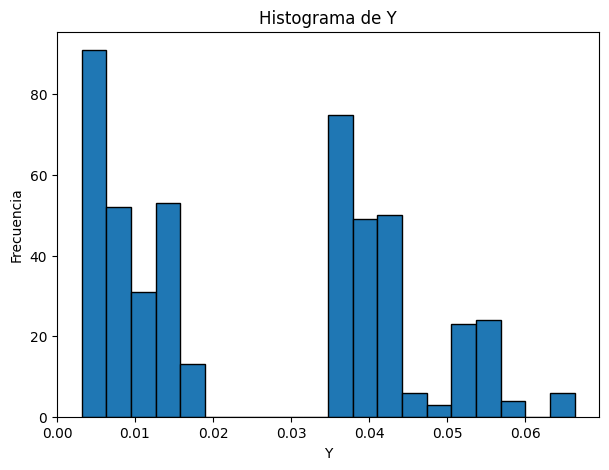

<Figure size 1400x600 with 0 Axes>

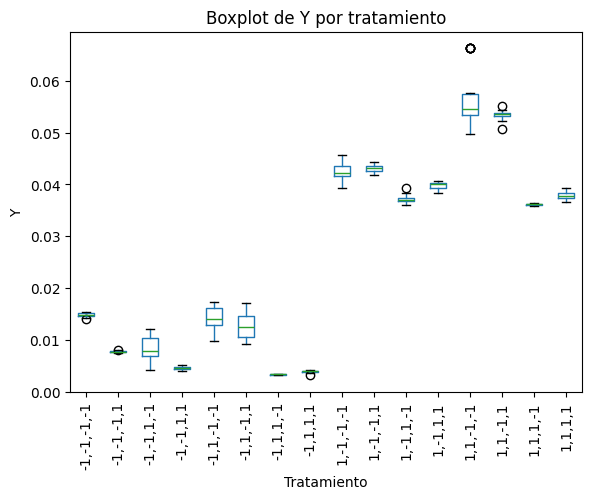

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     3622.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:37:47   Log-Likelihood:                 2382.4
No. Observations:                 480   AIC:                            -4733.
Df Residuals:                     464   BIC:                            -4666.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0260   7.85e-05    331.374      0.0

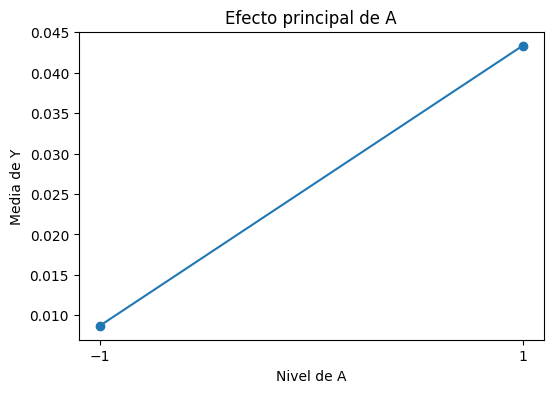

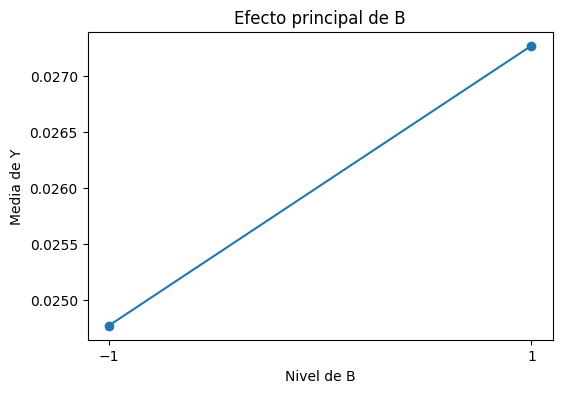

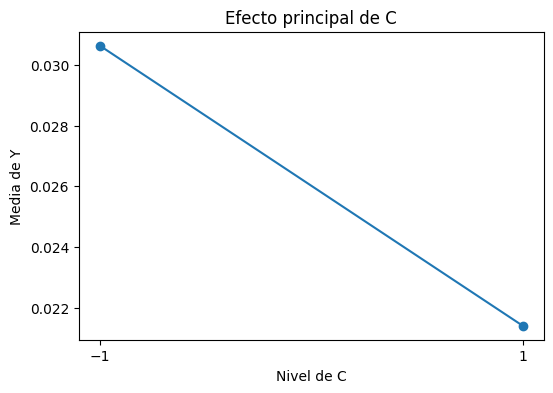

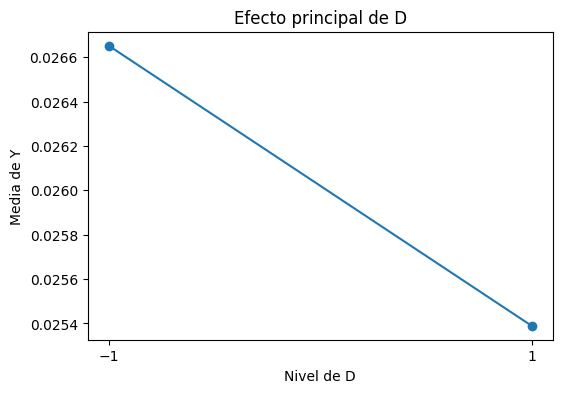

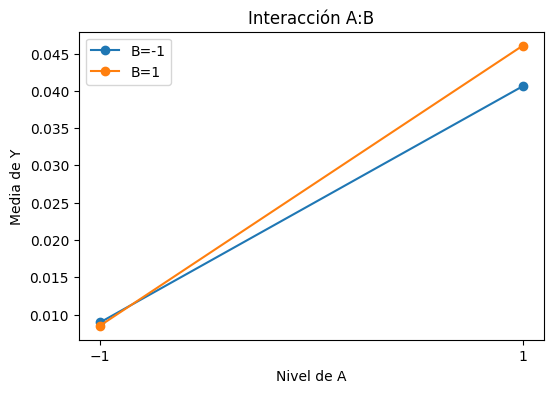

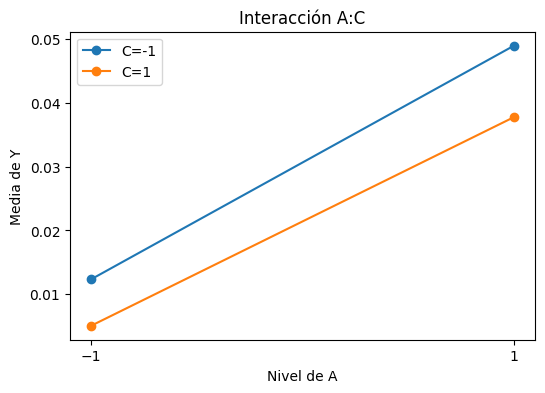

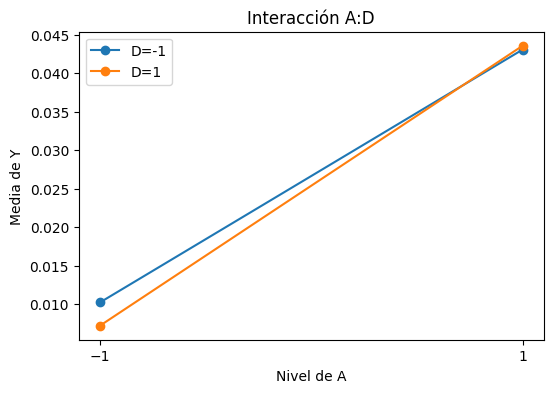

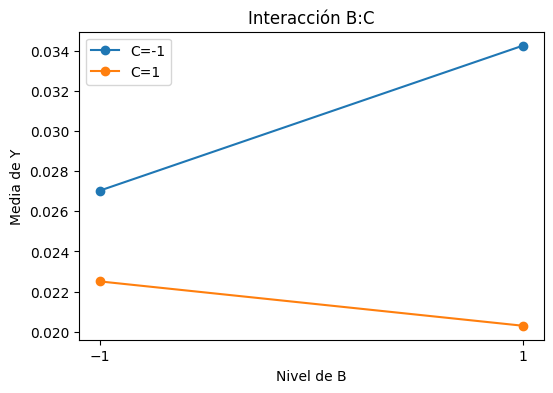

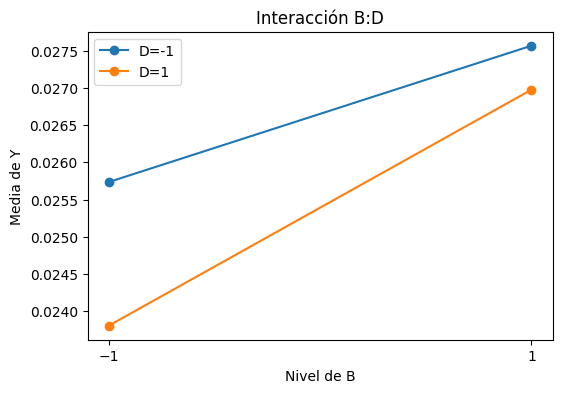

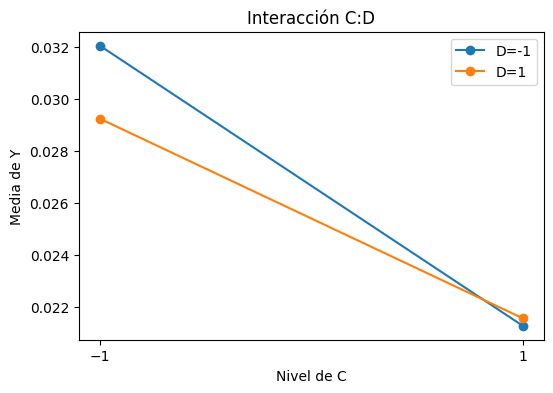

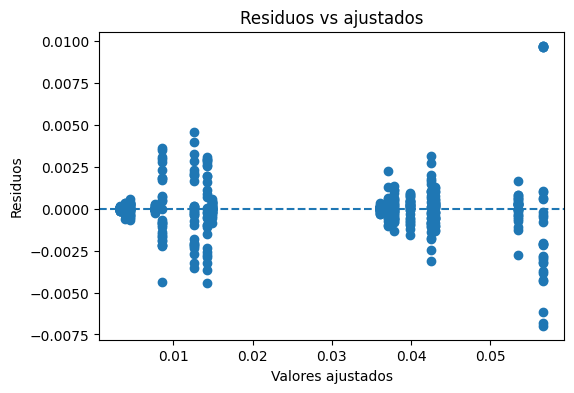

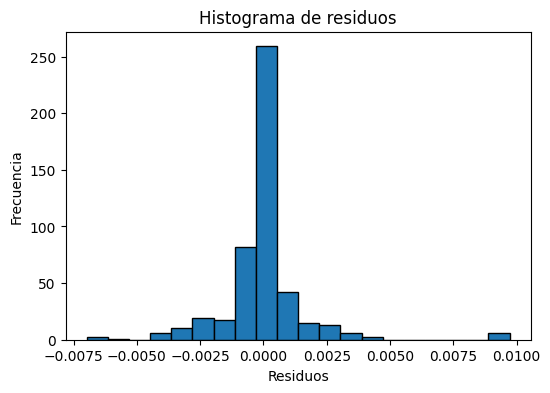

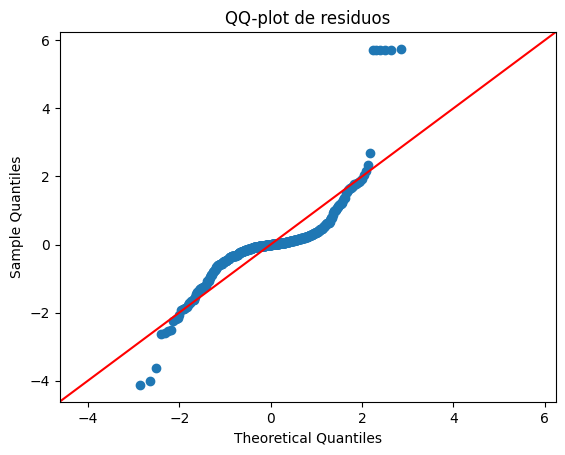

Shapiro-Wilk: 0.742916342231534 1.296146505091896e-26
Breusch-Pagan LM p-valor: 2.284336232341226e-27
Breusch-Pagan F p-valor: 4.673191663280858e-34


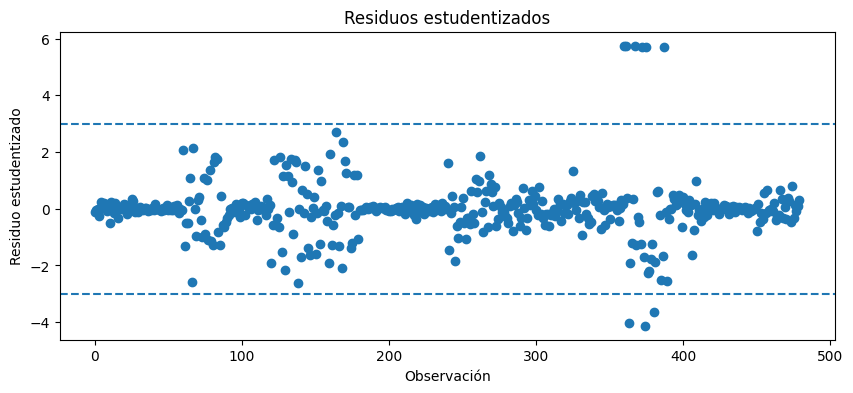

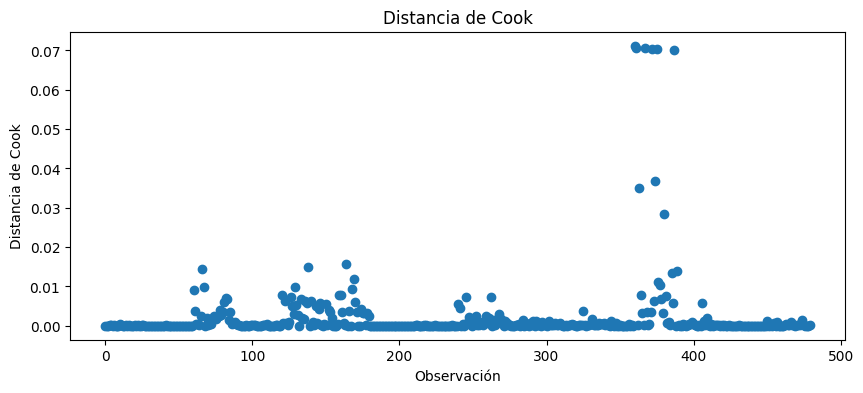

    A  B  C  D         Y
12  1  1 -1 -1  0.056632
13  1  1 -1  1  0.053517
9   1 -1 -1  1  0.043062
8   1 -1 -1 -1  0.042465
11  1 -1  1  1  0.039828
15  1  1  1  1  0.037898
10  1 -1  1 -1  0.037078
14  1  1  1 -1  0.036136
0  -1 -1 -1 -1  0.014859
4  -1  1 -1 -1  0.014205
5  -1  1 -1  1  0.012605
2  -1 -1  1 -1  0.008538
1  -1 -1 -1  1  0.007734
3  -1 -1  1  1  0.004592
7  -1  1  1  1  0.003884
6  -1  1  1 -1  0.003298


In [3]:

# 2) Revisiones básicas
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

for factor in ['A', 'B', 'C', 'D']:
    print(factor, sorted(df[factor].unique()))

conteos = df.groupby(['A', 'B', 'C', 'D']).size().reset_index(name='n')
print(conteos)
print(conteos['n'].value_counts())

# 3) Descriptivos
print(df['Y'].describe())

resumen = df.groupby(['A', 'B', 'C', 'D'])['Y'].agg(['mean', 'std', 'count']).reset_index()
print(resumen.sort_values(by='mean', ascending=False))

# 4) Etiqueta de tratamiento
df['tratamiento'] = (
    df['A'].astype(str) + ',' +
    df['B'].astype(str) + ',' +
    df['C'].astype(str) + ',' +
    df['D'].astype(str)
)

# 5) Histograma de Y
plt.figure(figsize=(7,5))
plt.hist(df['Y'], bins=20, edgecolor='black')
plt.xlabel('Y')
plt.ylabel('Frecuencia')
plt.title('Histograma de Y')
plt.show()

# 6) Boxplot por tratamiento
plt.figure(figsize=(14,6))
df.boxplot(column='Y', by='tratamiento', grid=False, rot=90)
plt.title('Boxplot de Y por tratamiento')
plt.suptitle('')
plt.xlabel('Tratamiento')
plt.ylabel('Y')
plt.show()

# 7) Modelo completo
modelo = smf.ols('Y ~ A*B*C*D', data=df).fit()
print(modelo.summary())

# 8) ANOVA
anova = anova_lm(modelo, typ=2)
print(anova)

# 9) Efectos estimados
print("Coeficientes:")
print(modelo.params)

print("Efectos factoriales estimados:")
print(2 * modelo.params)

# 10) Gráficos de efectos principales
for factor in ['A', 'B', 'C', 'D']:
    medias = df.groupby(factor)['Y'].mean()
    plt.figure(figsize=(6,4))
    plt.plot(medias.index, medias.values, marker='o')
    plt.xlabel(f'Nivel de {factor}')
    plt.ylabel('Media de Y')
    plt.title(f'Efecto principal de {factor}')
    plt.xticks([-1, 1])
    plt.show()

# 11) Gráficos de interacción
pares = [('A','B'), ('A','C'), ('A','D'), ('B','C'), ('B','D'), ('C','D')]

for f1, f2 in pares:
    medias = df.groupby([f1, f2])['Y'].mean().unstack()
    plt.figure(figsize=(6,4))
    for nivel in medias.columns:
        plt.plot(medias.index, medias[nivel], marker='o', label=f'{f2}={nivel}')
    plt.xlabel(f'Nivel de {f1}')
    plt.ylabel('Media de Y')
    plt.title(f'Interacción {f1}:{f2}')
    plt.xticks([-1, 1])
    plt.legend()
    plt.show()

# 12) Diagnóstico de residuos
residuos = modelo.resid
ajustados = modelo.fittedvalues

plt.figure(figsize=(6,4))
plt.scatter(ajustados, residuos)
plt.axhline(0, linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs ajustados')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuos, bins=20, edgecolor='black')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de residuos')
plt.show()

sm.qqplot(residuos, line='45', fit=True)
plt.title('QQ-plot de residuos')
plt.show()

# 13) Pruebas de supuestos
stat, p = shapiro(residuos)
print("Shapiro-Wilk:", stat, p)

lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(residuos, modelo.model.exog)
print("Breusch-Pagan LM p-valor:", lm_pvalue)
print("Breusch-Pagan F p-valor:", f_pvalue)

# 14) Observaciones influyentes
influencia = modelo.get_influence()
residuos_est = influencia.resid_studentized_internal
cook = influencia.cooks_distance[0]

plt.figure(figsize=(10,4))
plt.plot(residuos_est, marker='o', linestyle='none')
plt.axhline(3, linestyle='--')
plt.axhline(-3, linestyle='--')
plt.xlabel('Observación')
plt.ylabel('Residuo estudentizado')
plt.title('Residuos estudentizados')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(cook, marker='o', linestyle='none')
plt.xlabel('Observación')
plt.ylabel('Distancia de Cook')
plt.title('Distancia de Cook')
plt.show()

# 15) Mejor combinación observada
mejores = df.groupby(['A','B','C','D'])['Y'].mean().reset_index()
mejores = mejores.sort_values(by='Y', ascending=False)
print(mejores)

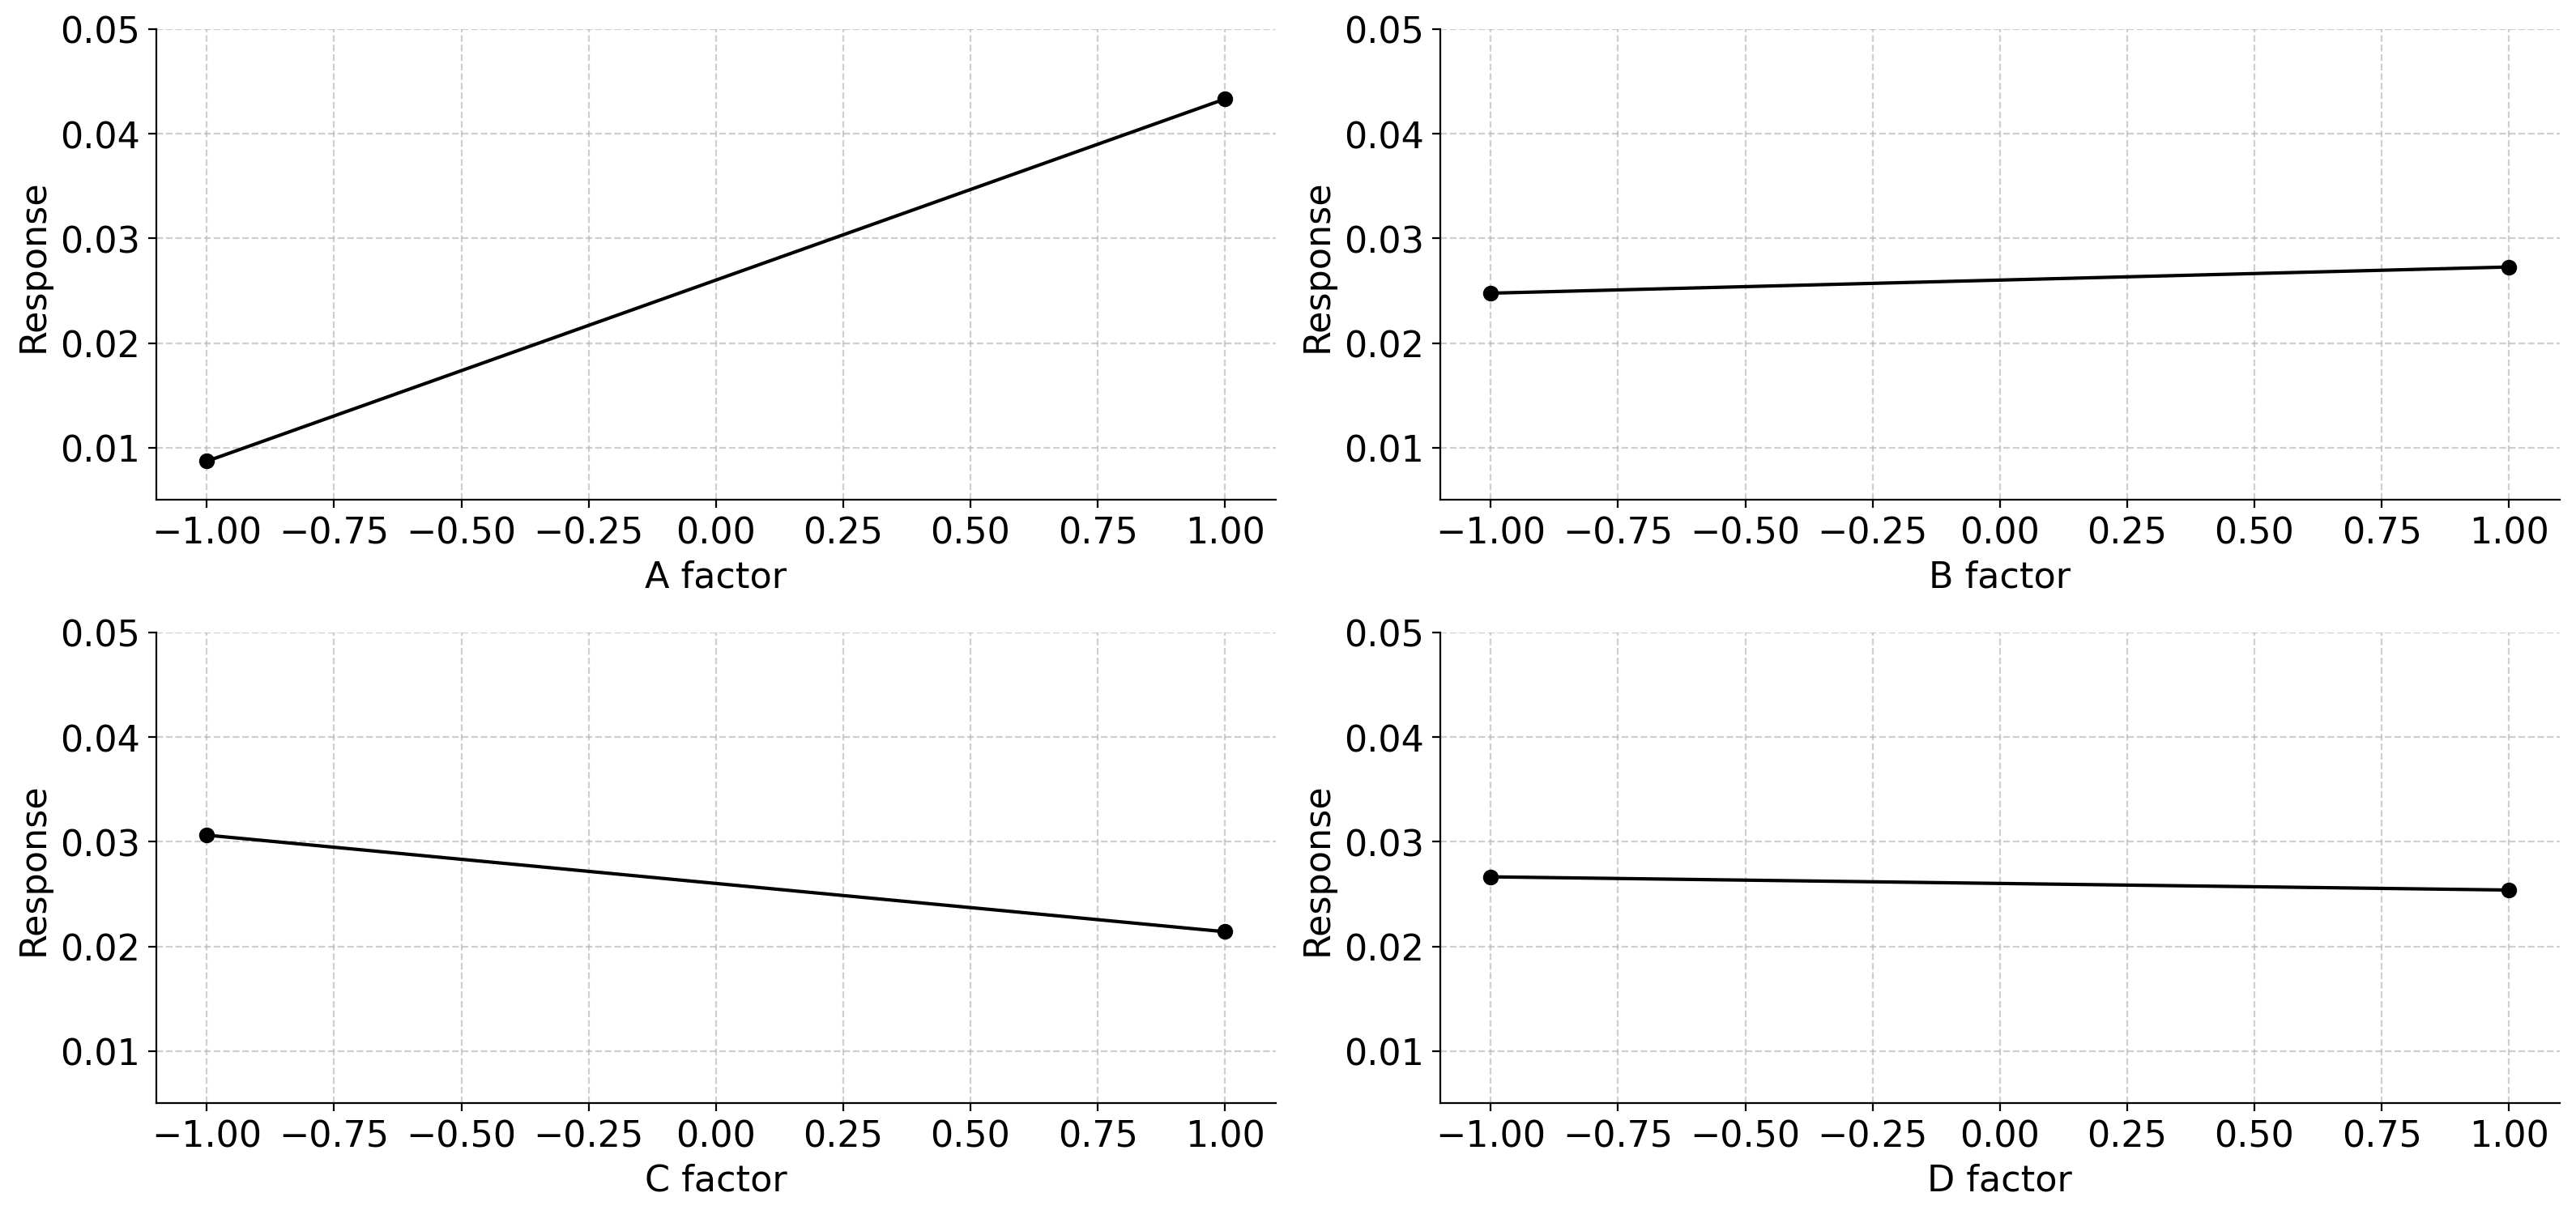

In [4]:
def efectos_principales(datos, factores, respuesta, filas, columnas, limites = None):
  # Crear una figura para todos los gráficos de efectos principales
  fig, axes = plt.subplots(filas, columnas, figsize=(16, 8), dpi = 200)  # Ajusta filas y columnas según el número de factores
  # fig.suptitle('Gráficos de Efectos Principales', fontsize=16)

  # Iterar sobre cada factor para graficar
  for i, factor in enumerate(factores):
      # Calcular medias de la respuesta para cada nivel del factor
      medias = datos.groupby(factor)[respuesta].mean()

      # Ubicar el subgráfico
      ax = axes[i // columnas, i % columnas]
      ax.plot(medias.index, medias.values, marker='o', linestyle='-', color='black')

      # Configuración del subgráfico
      ax.set_xlabel(f'{factor} factor', fontsize=16)
      ax.set_ylabel('Response', fontsize=16)
      ax.grid(True, linestyle='--', alpha=0.6)
      if limites is not None:
        ax.set_ylim(limites)

      # quitar bordes
      ax.spines['top'].set_visible(False)
      ax.spines['right'].set_visible(False)

      # cambiar el tamaño de fuente de los número de los ejes
      ax.tick_params(axis='both', labelsize=16)

  # Ajustar el diseño para evitar solapamientos
  plt.tight_layout(rect=[0, 0, 1, 0.95])
  plt.show()


efectos_principales(df, list('ABCD'), 'Y', 2, 2, [0.005, 0.05])
# efectos_principales(df, list('ABCD'), 'Y', 2, 2, [0.005, 0.05])

In [5]:
df

,A,B,C,D,Y,tratamiento
0,-1,-1,-1,-1,0.014638,"-1,-1,-1,-1"
1,-1,-1,-1,-1,0.014769,"-1,-1,-1,-1"
2,-1,-1,-1,-1,0.014821,"-1,-1,-1,-1"
3,-1,-1,-1,-1,0.014401,"-1,-1,-1,-1"
4,-1,-1,-1,-1,0.015232,"-1,-1,-1,-1"
...,...,...,...,...,...,...
475,1,1,1,1,0.037338,"1,1,1,1"
476,1,1,1,1,0.038129,"1,1,1,1"
477,1,1,1,1,0.037758,"1,1,1,1"
478,1,1,1,1,0.038049,"1,1,1,1"


Dimensiones: (480, 6)
   A  B  C  D         Y  tratamiento
0 -1 -1 -1 -1  0.014638  -1,-1,-1,-1
1 -1 -1 -1 -1  0.014769  -1,-1,-1,-1
2 -1 -1 -1 -1  0.014821  -1,-1,-1,-1
3 -1 -1 -1 -1  0.014401  -1,-1,-1,-1
4 -1 -1 -1 -1  0.015232  -1,-1,-1,-1
A              0
B              0
C              0
D              0
Y              0
tratamiento    0
dtype: int64

Conteos por tratamiento:
    A  B  C  D   n
0  -1 -1 -1 -1  30
1  -1 -1 -1  1  30
2  -1 -1  1 -1  30
3  -1 -1  1  1  30
4  -1  1 -1 -1  30
5  -1  1 -1  1  30
6  -1  1  1 -1  30
7  -1  1  1  1  30
8   1 -1 -1 -1  30
9   1 -1 -1  1  30
10  1 -1  1 -1  30
11  1 -1  1  1  30
12  1  1 -1 -1  30
13  1  1 -1  1  30
14  1  1  1 -1  30
15  1  1  1  1  30

Frecuencia de conteos:
n
30    16
Name: count, dtype: int64

Medias por tratamiento:
    A  B  C  D         Y
0  -1 -1 -1 -1  0.014859
1  -1 -1 -1  1  0.007734
2  -1 -1  1 -1  0.008538
3  -1 -1  1  1  0.004592
4  -1  1 -1 -1  0.014205
5  -1  1 -1  1  0.012605
6  -1  1  1 -1  0.003298
7  -1 

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


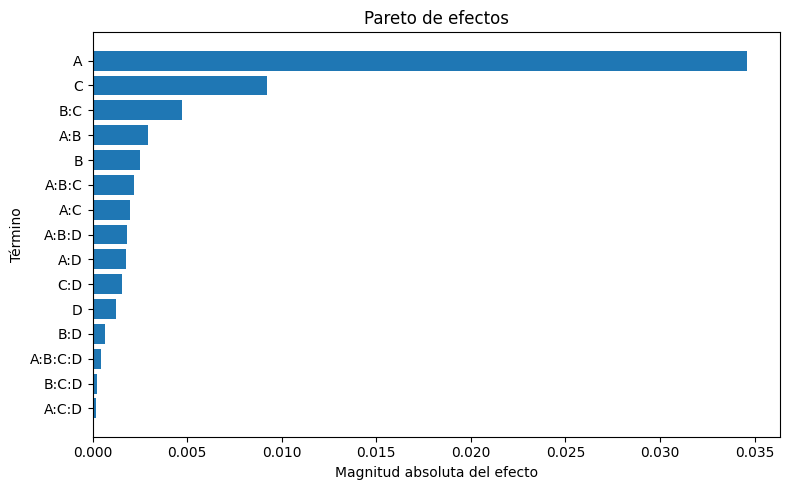

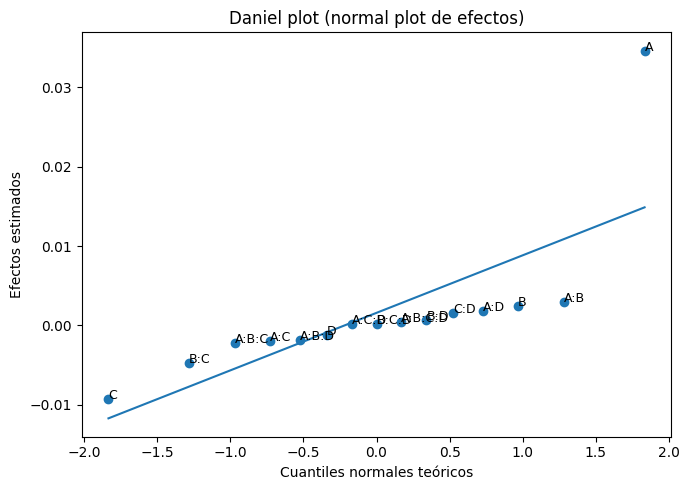


Mejores combinaciones para MAXIMIZAR Y:
    A  B  C  D         Y
0   1  1 -1 -1  0.056632
1   1  1 -1  1  0.053517
2   1 -1 -1  1  0.043062
3   1 -1 -1 -1  0.042465
4   1 -1  1  1  0.039828
5   1  1  1  1  0.037898
6   1 -1  1 -1  0.037078
7   1  1  1 -1  0.036136
8  -1 -1 -1 -1  0.014859
9  -1  1 -1 -1  0.014205
10 -1  1 -1  1  0.012605
11 -1 -1  1 -1  0.008538
12 -1 -1 -1  1  0.007734
13 -1 -1  1  1  0.004592
14 -1  1  1  1  0.003884
15 -1  1  1 -1  0.003298

Mejores combinaciones para MINIMIZAR Y:
    A  B  C  D         Y
0  -1  1  1 -1  0.003298
1  -1  1  1  1  0.003884
2  -1 -1  1  1  0.004592
3  -1 -1 -1  1  0.007734
4  -1 -1  1 -1  0.008538
5  -1  1 -1  1  0.012605
6  -1  1 -1 -1  0.014205
7  -1 -1 -1 -1  0.014859
8   1  1  1 -1  0.036136
9   1 -1  1 -1  0.037078
10  1  1  1  1  0.037898
11  1 -1  1  1  0.039828
12  1 -1 -1 -1  0.042465
13  1 -1 -1  1  0.043062
14  1  1 -1  1  0.053517
15  1  1 -1 -1  0.056632

Comparación de efectos:
    Termino  Efecto_medias  Efecto_base_com

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

# =========================================================
# 1) CARGAR DATOS
# =========================================================
# df = pd.read_csv("diseno_2_4.csv")

# Verificación básica
print("Dimensiones:", df.shape)
print(df.head())
print(df.isnull().sum())

# =========================================================
# 2) REVISIÓN DEL BALANCE DEL DISEÑO
# =========================================================
conteos = df.groupby(['A', 'B', 'C', 'D']).size().reset_index(name='n')
print("\nConteos por tratamiento:")
print(conteos)

print("\nFrecuencia de conteos:")
print(conteos['n'].value_counts())

# =========================================================
# 3) MEDIAS POR TRATAMIENTO
# =========================================================
medias = df.groupby(['A', 'B', 'C', 'D'])['Y'].mean().reset_index()
medias = medias.sort_values(['A', 'B', 'C', 'D']).reset_index(drop=True)

print("\nMedias por tratamiento:")
print(medias)

# =========================================================
# 4) AJUSTE DEL MODELO CON MEDIAS
#    En un 2^4 completo, esto reproduce exactamente los 16
#    promedios de tratamiento.
# =========================================================
modelo_medias = smf.ols('Y ~ A*B*C*D', data=medias).fit()

print("\nResumen del modelo con medias:")
print(modelo_medias.summary())

# =========================================================
# 5) EFECTOS FACTORIALES
#    En codificación -1/+1:
#    efecto = 2 * coeficiente
# =========================================================
coef = modelo_medias.params.drop('Intercept')
efectos = 2 * coef

tabla_efectos = pd.DataFrame({
    'Termino': efectos.index,
    'Coeficiente': coef.values,
    'Efecto': efectos.values,
    'Abs_Efecto': np.abs(efectos.values)
}).sort_values('Abs_Efecto', ascending=False).reset_index(drop=True)

print("\nTabla de efectos (ordenada):")
print(tabla_efectos)

# Guardar tabla si quieres
tabla_efectos.to_csv("tabla_efectos_factorial.csv", index=False)

# =========================================================
# 6) PARETO DE EFECTOS
# =========================================================
plt.figure(figsize=(8, 5))
plt.barh(tabla_efectos['Termino'], tabla_efectos['Abs_Efecto'])
plt.gca().invert_yaxis()
plt.xlabel('Magnitud absoluta del efecto')
plt.ylabel('Término')
plt.title('Pareto de efectos')
plt.tight_layout()
plt.show()

# =========================================================
# 7) DANIEL PLOT (NORMAL PLOT DE EFECTOS)
#    Se grafican los efectos ordenados vs cuantiles normales
# =========================================================
ef_sorted = np.sort(efectos.values)
n = len(ef_sorted)

# Cuantiles teóricos normales
prob = (np.arange(1, n + 1) - 0.5) / n
z = stats.norm.ppf(prob)

# Para etiquetar correctamente
orden = np.argsort(efectos.values)
terminos_ordenados = efectos.index[orden]

plt.figure(figsize=(7, 5))
plt.scatter(z, ef_sorted)

for xi, yi, lab in zip(z, ef_sorted, terminos_ordenados):
    plt.text(xi, yi, lab, fontsize=9)

# Línea de referencia simple
coef_linea = np.polyfit(z, ef_sorted, 1)
xline = np.linspace(z.min(), z.max(), 100)
yline = coef_linea[0] * xline + coef_linea[1]
plt.plot(xline, yline)

plt.xlabel('Cuantiles normales teóricos')
plt.ylabel('Efectos estimados')
plt.title('Daniel plot (normal plot de efectos)')
plt.tight_layout()
plt.show()

# =========================================================
# 8) MEJOR COMBINACIÓN OBSERVADA
# =========================================================
mejores = df.groupby(['A', 'B', 'C', 'D'])['Y'].mean().reset_index()
mejores_max = mejores.sort_values('Y', ascending=False).reset_index(drop=True)
mejores_min = mejores.sort_values('Y', ascending=True).reset_index(drop=True)

print("\nMejores combinaciones para MAXIMIZAR Y:")
print(mejores_max)

print("\nMejores combinaciones para MINIMIZAR Y:")
print(mejores_min)

# =========================================================
# 9) EFECTOS CALCULADOS DIRECTAMENTE DESDE LA BASE COMPLETA
#    (no solo con medias)
#    Para comparar consistencia
# =========================================================
modelo_completo = smf.ols('Y ~ A*B*C*D', data=df).fit()
coef_completo = modelo_completo.params.drop('Intercept')
efectos_completo = 2 * coef_completo

tabla_comparacion = pd.DataFrame({
    'Termino': efectos.index,
    'Efecto_medias': efectos.values,
    'Efecto_base_completa': efectos_completo.reindex(efectos.index).values
})

tabla_comparacion['Diferencia'] = (
    tabla_comparacion['Efecto_base_completa'] -
    tabla_comparacion['Efecto_medias']
)

print("\nComparación de efectos:")
print(tabla_comparacion)

tabla_comparacion.to_csv("comparacion_efectos.csv", index=False)

# =========================================================
# 10) INTERPRETACIÓN AUTOMÁTICA SIMPLE
# =========================================================
print("\nRanking de efectos más grandes:")
for i, row in tabla_efectos.head(10).iterrows():
    signo = "aumenta" if row['Efecto'] > 0 else "disminuye"
    print(f"{i+1}. {row['Termino']}: efecto = {row['Efecto']:.6f} ({signo} Y al pasar de nivel bajo a alto, sujeto a interacciones)")

In [ ]:
# =========================================================
# 1) CARGAR BASE
# =========================================================
df = pd.read_csv("diseno_2_4.csv")

print("Dimensiones de la base:", df.shape)
print(df.head())
print("\nValores únicos de A:", sorted(df["A"].unique()))
print("Valores únicos de B:", sorted(df["B"].unique()))
print("Valores únicos de C:", sorted(df["C"].unique()))
print("Valores únicos de D:", sorted(df["D"].unique()))


# =========================================================
# 2) SEPARAR POR TIPO DE PROBLEMA
#    A = -1  -> CSTR moderadamente lineal
#    A =  1  -> CSTR no lineal
# =========================================================
df_lineal = df[df["A"] == -1].copy()
df_nolineal = df[df["A"] == 1].copy()

print("\nTamaño subconjunto lineal:", df_lineal.shape)
print("Tamaño subconjunto no lineal:", df_nolineal.shape)


# =========================================================
# 3) FUNCIÓN GENERAL PARA ANALIZAR CADA PROBLEMA
# =========================================================
def analizar_factorial_2_3(datos, nombre_problema):
    print("\n" + "="*70)
    print(f"ANÁLISIS PARA: {nombre_problema}")
    print("="*70)

    # -----------------------------------------------------
    # 3.1 Verificar balance del diseño 2^3
    # -----------------------------------------------------
    conteos = datos.groupby(["B", "C", "D"]).size().reset_index(name="n")
    print("\nConteos por tratamiento:")
    print(conteos)

    print("\nFrecuencia de conteos:")
    print(conteos["n"].value_counts())

    # -----------------------------------------------------
    # 3.2 Descriptivos generales
    # -----------------------------------------------------
    print("\nResumen de Y:")
    print(datos["Y"].describe())

    resumen = datos.groupby(["B", "C", "D"])["Y"].agg(["mean", "std", "count"]).reset_index()
    resumen = resumen.sort_values("mean", ascending=False).reset_index(drop=True)

    print("\nResumen por tratamiento:")
    print(resumen)

    # -----------------------------------------------------
    # 3.3 Histograma de Y
    # -----------------------------------------------------
    plt.figure(figsize=(6, 4))
    plt.hist(datos["Y"], bins=15, edgecolor="black")
    plt.xlabel("Y")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de Y - {nombre_problema}")
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # 3.4 Boxplot por tratamiento
    # -----------------------------------------------------
    datos = datos.copy()
    datos["tratamiento"] = (
        datos["B"].astype(str) + "," +
        datos["C"].astype(str) + "," +
        datos["D"].astype(str)
    )

    plt.figure(figsize=(10, 5))
    datos.boxplot(column="Y", by="tratamiento", grid=False, rot=0)
    plt.title(f"Boxplot por tratamiento - {nombre_problema}")
    plt.suptitle("")
    plt.xlabel("Tratamiento (B,C,D)")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # 3.5 Ajustar modelo factorial 2^3
    # -----------------------------------------------------
    modelo = smf.ols("Y ~ B*C*D", data=datos).fit()

    print("\nResumen del modelo:")
    print(modelo.summary())

    # -----------------------------------------------------
    # 3.6 ANOVA
    # -----------------------------------------------------
    anova = anova_lm(modelo, typ=2)
    print("\nANOVA:")
    print(anova)

    # -----------------------------------------------------
    # 3.7 Efectos factoriales
    #     En codificación -1/+1: efecto = 2 * coeficiente
    # -----------------------------------------------------
    coef = modelo.params.drop("Intercept")
    efectos = 2 * coef

    tabla_efectos = pd.DataFrame({
        "Termino": efectos.index,
        "Coeficiente": coef.values,
        "Efecto": efectos.values,
        "Abs_Efecto": np.abs(efectos.values)
    }).sort_values("Abs_Efecto", ascending=False).reset_index(drop=True)

    print("\nTabla de efectos:")
    print(tabla_efectos)

    # -----------------------------------------------------
    # 3.8 Pareto de efectos
    # -----------------------------------------------------
    plt.figure(figsize=(7, 4))
    plt.barh(tabla_efectos["Termino"], tabla_efectos["Abs_Efecto"])
    plt.gca().invert_yaxis()
    plt.xlabel("Magnitud absoluta del efecto")
    plt.ylabel("Término")
    plt.title(f"Pareto de efectos - {nombre_problema}")
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # 3.9 Daniel plot
    # -----------------------------------------------------
    ef_vals = efectos.values
    ef_sorted = np.sort(ef_vals)
    n = len(ef_sorted)

    prob = (np.arange(1, n + 1) - 0.5) / n
    z = stats.norm.ppf(prob)

    orden = np.argsort(ef_vals)
    terminos_ordenados = efectos.index[orden]

    plt.figure(figsize=(7, 5))
    plt.scatter(z, ef_sorted)

    for xi, yi, lab in zip(z, ef_sorted, terminos_ordenados):
        plt.text(xi, yi, lab, fontsize=9)

    coef_linea = np.polyfit(z, ef_sorted, 1)
    xline = np.linspace(z.min(), z.max(), 100)
    yline = coef_linea[0] * xline + coef_linea[1]
    plt.plot(xline, yline)

    plt.xlabel("Cuantiles normales teóricos")
    plt.ylabel("Efectos estimados")
    plt.title(f"Daniel plot - {nombre_problema}")
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # 3.10 Efectos principales
    # -----------------------------------------------------
    for factor in ["B", "C", "D"]:
        medias = datos.groupby(factor)["Y"].mean()

        plt.figure(figsize=(5, 4))
        plt.plot(medias.index, medias.values, marker="o")
        plt.xlabel(f"Nivel de {factor}")
        plt.ylabel("Media de Y")
        plt.title(f"Efecto principal de {factor} - {nombre_problema}")
        plt.xticks([-1, 1])
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------
    # 3.11 Interacciones dobles
    # -----------------------------------------------------
    pares = [("B", "C"), ("B", "D"), ("C", "D")]

    for f1, f2 in pares:
        medias = datos.groupby([f1, f2])["Y"].mean().unstack()

        plt.figure(figsize=(5, 4))
        for nivel in medias.columns:
            plt.plot(medias.index, medias[nivel], marker="o", label=f"{f2}={nivel}")

        plt.xlabel(f"Nivel de {f1}")
        plt.ylabel("Media de Y")
        plt.title(f"Interacción {f1}:{f2} - {nombre_problema}")
        plt.xticks([-1, 1])
        plt.legend()
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------
    # 3.12 Diagnóstico de residuos
    # -----------------------------------------------------
    residuos = modelo.resid
    ajustados = modelo.fittedvalues

    # Residuos vs ajustados
    plt.figure(figsize=(5, 4))
    plt.scatter(ajustados, residuos)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Valores ajustados")
    plt.ylabel("Residuos")
    plt.title(f"Residuos vs ajustados - {nombre_problema}")
    plt.tight_layout()
    plt.show()

    # Histograma de residuos
    plt.figure(figsize=(5, 4))
    plt.hist(residuos, bins=15, edgecolor="black")
    plt.xlabel("Residuos")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de residuos - {nombre_problema}")
    plt.tight_layout()
    plt.show()

    # QQ-plot
    sm.qqplot(residuos, line="45", fit=True)
    plt.title(f"QQ-plot de residuos - {nombre_problema}")
    plt.tight_layout()
    plt.show()

    # Shapiro
    sh_stat, sh_p = shapiro(residuos)
    print("\nShapiro-Wilk:")
    print("Estadístico =", sh_stat)
    print("p-valor     =", sh_p)

    # Breusch-Pagan
    lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(residuos, modelo.model.exog)
    print("\nBreusch-Pagan:")
    print("LM p-valor =", lm_pvalue)
    print("F  p-valor =", f_pvalue)

    # -----------------------------------------------------
    # 3.13 Mejor combinación observada
    # -----------------------------------------------------
    mejores = datos.groupby(["B", "C", "D"])["Y"].mean().reset_index()
    mejores_max = mejores.sort_values("Y", ascending=False).reset_index(drop=True)
    mejores_min = mejores.sort_values("Y", ascending=True).reset_index(drop=True)

    print("\nMejores combinaciones para MAXIMIZAR Y:")
    print(mejores_max)

    print("\nMejores combinaciones para MINIMIZAR Y:")
    print(mejores_min)

    # -----------------------------------------------------
    # 3.14 Devolver objetos útiles
    # -----------------------------------------------------
    return {
        "modelo": modelo,
        "anova": anova,
        "tabla_efectos": tabla_efectos,
        "resumen_tratamientos": resumen,
        "mejores_max": mejores_max,
        "mejores_min": mejores_min
    }


# =========================================================
# 4) ANALIZAR CADA PROBLEMA POR SEPARADO
# =========================================================
resultados_lineal = analizar_factorial_2_3(
    df_lineal,
    "CSTR moderadamente lineal"
)

resultados_nolineal = analizar_factorial_2_3(
    df_nolineal,
    "CSTR no lineal"
)


# =========================================================
# 5) COMPARACIÓN FINAL DE EFECTOS ENTRE PROBLEMAS
# =========================================================
ef_lineal = resultados_lineal["tabla_efectos"][["Termino", "Efecto"]].rename(
    columns={"Efecto": "Efecto_lineal"}
)

ef_nolineal = resultados_nolineal["tabla_efectos"][["Termino", "Efecto"]].rename(
    columns={"Efecto": "Efecto_nolineal"}
)

comparacion = ef_lineal.merge(ef_nolineal, on="Termino")
comparacion["Dif_abs"] = np.abs(comparacion["Efecto_lineal"] - comparacion["Efecto_nolineal"])

print("\n" + "="*70)
print("COMPARACIÓN DE EFECTOS ENTRE AMBOS PROBLEMAS")
print("="*70)
print(comparacion.sort_values("Dif_abs", ascending=False))


# =========================================================
# 6) GRÁFICO COMPARATIVO DE EFECTOS
# =========================================================
comparacion_plot = comparacion.set_index("Termino")

x = np.arange(len(comparacion_plot))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, comparacion_plot["Efecto_lineal"], width, label="Lineal")
plt.bar(x + width/2, comparacion_plot["Efecto_nolineal"], width, label="No lineal")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, comparacion_plot.index, rotation=45)
plt.ylabel("Efecto estimado")
plt.title("Comparación de efectos entre problemas")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats

# ========================================
# 1. Cargar datos
# ========================================

df = pd.read_csv("diseno_2_4.csv")

print("Primeras filas:")
print(df.head())

# ========================================
# 2. Normalizar RMSE por sistema (A)
# ========================================

media_sistema = df.groupby("A")["Y"].transform("mean")

df["Y_norm"] = df["Y"] / media_sistema

print("\nResumen RMSE normalizado:")
print(df.groupby("A")["Y_norm"].describe())

# ========================================
# 3. Modelo factorial 2^4
# ========================================

modelo = smf.ols("Y_norm ~ A*B*C*D", data=df).fit()

print("\nResumen del modelo:")
print(modelo.summary())

# ========================================
# 4. ANOVA
# ========================================

anova = anova_lm(modelo, typ=2)

print("\nANOVA:")
print(anova)

# ========================================
# 5. Tabla de efectos factoriales
# ========================================

coef = modelo.params.drop("Intercept")

effects = 2 * coef

tabla_efectos = pd.DataFrame({
    "Termino": effects.index,
    "Efecto": effects.values,
    "Abs_Efecto": np.abs(effects.values)
})

tabla_efectos = tabla_efectos.sort_values("Abs_Efecto", ascending=False)

print("\nTabla de efectos:")
print(tabla_efectos)

# ========================================
# 6. Pareto plot
# ========================================

tabla_plot = tabla_efectos.sort_values("Abs_Efecto")

plt.figure(figsize=(8,5))
plt.barh(tabla_plot["Termino"], tabla_plot["Abs_Efecto"])
plt.xlabel("Absolute Effect")
plt.title("Pareto Plot of Effects")
plt.tight_layout()
plt.show()

# ========================================
# 7. Daniel plot
# ========================================

ef = effects.values

ef_sorted = np.sort(ef)

n = len(ef_sorted)

prob = (np.arange(1, n+1) - 0.5) / n

z = stats.norm.ppf(prob)

orden = np.argsort(ef)
labels = effects.index[orden]

plt.figure(figsize=(6,6))

plt.scatter(z, ef_sorted)

for xi, yi, lab in zip(z, ef_sorted, labels):
    plt.text(xi, yi, lab)

coef_line = np.polyfit(z, ef_sorted, 1)

xline = np.linspace(z.min(), z.max(), 100)
yline = coef_line[0]*xline + coef_line[1]

plt.plot(xline, yline)

plt.xlabel("Normal Quantiles")
plt.ylabel("Effects")
plt.title("Daniel Plot")
plt.tight_layout()
plt.show()

# ========================================
# 8. Main effects plots
# ========================================

factores = ["A","B","C","D"]

for f in factores:

    medias = df.groupby(f)["Y_norm"].mean()

    plt.figure()

    plt.plot(medias.index, medias.values, marker='o')

    plt.xlabel(f)
    plt.ylabel("Mean Normalized RMSE")

    plt.title(f"Main Effect: {f}")

    plt.xticks([-1,1])

    plt.tight_layout()

    plt.show()

# ========================================
# 9. Interaction plots con A
# ========================================

otros_factores = ["B","C","D"]

for f in otros_factores:

    medias = df.groupby(["A",f])["Y_norm"].mean().unstack()

    plt.figure()

    for nivel in medias.columns:

        plt.plot(medias.index, medias[nivel], marker='o', label=f"{f}={nivel}")

    plt.xlabel("A (System Type)")
    plt.ylabel("Mean Normalized RMSE")

    plt.title(f"Interaction A × {f}")

    plt.xticks([-1,1])

    plt.legend()

    plt.tight_layout()

    plt.show()

# ========================================
# 10. Guardar base normalizada
# ========================================

df.to_csv("diseno_2_4_normalizado.csv", index=False)

print("\nArchivo normalizado guardado.")